# ราคารถมือสอง — Multiple Linear Regression (MLR) ที่ผ่าน 5 assumption (เวอร์ชัน 3)
- ข้อมูล, การรวมชื่อรุ่น และการแบ่ง train/val/test (80 / 10 / 10) ใช้ชุดเดียวกับ DT3 / RF3 / XGB3
- ตัวแปรที่ใช้ **ไม่ได้กำหนดเอง** แต่เลือกจาก train ในหัวข้อ 5 (กรองตัวซ้ำซ้อน + GVIF + backward elimination ด้วย F-test และ CV MAE)
- โมเดลสุดท้ายใช้ตัวช่วยแก้ assumption หลายอย่างพร้อมกัน (อธิบายในหัวข้อ 6): Box-Cox, FGLS, ตัด outlier, กลุ่มรุ่นรถ, age², slope อายุแยกยี่ห้อ ฯลฯ
- ทดสอบ assumption ครบ **5 กลุ่ม**: Independence, Homoscedasticity, Normality, Multicollinearity และ **Linearity (Ramsey RESET)**
- notebook นี้รันจากบนลงล่างได้เอง ใช้แค่ไฟล์ CSV

> ต้อง mount Google Drive ก่อนรัน

## 0. Import และค่าตั้งต้น
รวมค่าที่ใช้ทั้ง notebook ไว้ที่เดียว จะได้แก้ง่าย (สัดส่วน train/val/test ก็อยู่ตรงนี้)

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")   # บนเครื่องที่มีหลาย core การใช้ thread เยอะเกินทำให้ OpenBLAS ช้าลงมาก (บน Colab ไม่มีผล)
import time
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.special import boxcox, inv_boxcox
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.diagnostic import lilliefors, linear_reset
from statsmodels.stats.stattools import durbin_watson

DATA_PATH = "/content/drive/MyDrive/Project/cardb/car_dataset_v5.1.csv"
# ใช้รันในเครื่อง: ถ้าไม่เจอ path ของ Drive ให้ใช้ไฟล์ในเครื่องแทน (บน Colab ไม่มีผล)
if not os.path.exists(DATA_PATH):
    DATA_PATH = r"D:\Claude\new_project\data\car_dataset_v5.1.csv"

SEED = 99            # เลขสุ่มคงที่ รันกี่ครั้งก็ได้ผลเหมือนเดิม
MAX_CAR_AGE = 25     # ตัดรถอายุเกิน 25 ปีออก (รถคลาสสิก / รถสะสม)
TRAIN_SIZE = 0.8
VAL_SIZE = 0.1
TEST_SIZE = 0.1

EXPECTED_SHA256 = "d2c6f2c9f6a601406920c9c6fe2da71807137ef4590136f4a621f304f44fa96b"   # ลายนิ้วมือของไฟล์ข้อมูล (ตัด \r ออกก่อนคำนวณ)
REDUNDANT_MAX = 0.95   # คู่ตัวแปรที่สัมพันธ์กันตั้งแต่ค่านี้ขึ้นไป ถือว่าซ้ำซ้อน
TOL = 0.02             # ตัดตัวแปรได้ ถ้า CV MAE แย่ลงไม่เกิน 2%
N_FOLDS = 5            # จำนวน fold ของ cross-validation

NUM_COLS = ["engine_capacity", "mileage", "car_age"]                              # ตัวแปรตัวเลข
CAT_COLS = ["brand", "model", "car_type", "fuel_type", "gear_type", "color"]      # ตัวแปรกลุ่ม

# ชื่อรุ่นที่เขียนต่างกันแต่เป็นรุ่นเดียวกัน
MODEL_ALIASES = {"ALTIS": "COROLLAALTIS", "NP300NAVARA": "NAVARA"}

pd.set_option("display.width", 200, "display.max_columns", 50)

# --- ค่าตั้งต้นเฉพาะ MLR ---
ALPHA = 0.05                 # ระดับนัยสำคัญของทุก test (ผ่านเมื่อ p > ALPHA)
DW_RANGE = (1.5, 2.5)        # Durbin-Watson ผ่านเมื่ออยู่ในช่วงนี้
VIF_MAX = 7.0                # VIF / GVIF ต้องน้อยกว่าค่านี้
SW_MAX_N = 5000              # Shapiro-Wilk ใช้ได้ถึง n = 5,000 ถ้ามากกว่านั้นสุ่มมา 5,000 ตัว
RESET_POWER = 3              # Ramsey RESET: เติม ŷ², ŷ³ เข้าไปในโมเดลแล้วดูว่าดีขึ้นอย่างมีนัยสำคัญไหม

BOXCOX_LAMBDA = 0.08         # แปลง target ด้วย Box-Cox (0 = log) ให้ residual สมมาตร
AGE_CENTRE = 7               # อายุรถถูกลบด้วยค่านี้ก่อนทำ age² และ slope แยกยี่ห้อ (ลด collinearity)
SLOPE_BRAND_MIN = 100        # ยี่ห้อที่มี train >= ค่านี้ ได้ slope อายุของตัวเอง ที่เหลือใช้ slope ร่วม
KM_UNKNOWN_MAX = 2_500       # รถอายุ >= KM_UNKNOWN_MIN_AGE ปี แต่ไมล์ <= ค่านี้ ถือว่า "ไม่ทราบไมล์"
KM_UNKNOWN_MIN_AGE = 2
FGLS_ITERS = 5               # จำนวนรอบ WLS <-> โมเดลความแปรปรวน
VAR_RIDGE = 5.0              # ridge penalty ของโมเดลความแปรปรวน
OUTLIER_CUT = 3.5            # ตัดแถว train ที่ |studentized residual| > ค่านี้ แล้ว fit ใหม่จนไม่เหลือ
OUTLIER_MAX_ROUNDS = 15
EXPENSIVE_MIN = 2_000_000    # รุ่นหายากที่ราคามัธยฐานใน train >= ค่านี้ -> กลุ่ม "รถราคาแพง"
EXPENSIVE_LABEL = "รถราคาแพง"
RARE_MIN = 30                # ระดับของ fuel/gear/color และกลุ่ม OTHER_<ยี่ห้อ> ต้องมี train อย่างน้อยเท่านี้
RARE_MIN_MODEL = 3           # รุ่นที่มี train >= ค่านี้ ได้ dummy ของตัวเอง
RARE_LABEL = {"color": "Others"}
PRICE_TIERS = [0, 500_000, 1_500_000, 5_000_000, float("inf")]   # ระดับราคามัธยฐานของยี่ห้อ
TIER_LABELS = ["BUDGET", "MID", "PREMIUM", "EXOTIC"]
CENTRE_WITHIN_MODEL = ["engine_capacity", "fuel_type_Diesel", "fuel_type_Hybrid"]   # x - ค่าเฉลี่ยของรุ่น: fit เท่าเดิม VIF ต่ำลง

plt.rcParams["font.family"] = ["Tahoma", "DejaVu Sans"]   # Tahoma มีตัวอักษรไทย (รถราคาแพง)

## 1. โหลดข้อมูล
อ่านไฟล์ CSV เข้ามาเป็นตาราง (`DataFrame`) ยังไม่แก้ไขอะไร

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(30104, 11)


,brand,model,car_type,fuel_type,gear_type,color,engine_capacity,mileage,year,car_age,price
0,HONDA,CITY,Sedan,Benzine,Automatic,Red,1000,62000,2020,6,419000
1,FORD,EVEREST,SUV,Diesel,Automatic,White,2000,130000,2012,14,849000
2,HONDA,CIVIC,Hatchback,Benzine,Automatic,Grey,1500,103000,2021,5,759000
3,TOYOTA,FORTUNER,PPV,Diesel,Automatic,Black,2800,57000,2022,4,1069000
4,TOYOTA,ALPHARD,Van,Benzine,Automatic,White,2500,61800,2022,4,2188000


## 2. ตรวจข้อมูล (data check)
ข้อมูลชุดนี้ทำความสะอาดมาแล้ว ขั้นนี้ **แค่ตรวจและรายงาน** ไม่ได้เรียนรู้อะไรจากข้อมูล ไม่แก้ข้อมูล
- ตรวจ **sha256** ของไฟล์ (ลายนิ้วมือของไฟล์) ว่าเป็นไฟล์เวอร์ชันเดียวกับที่ใช้ทำผลทั้งหมด ถ้าไม่ตรงโค้ดจะหยุดทันที (ตัดตัวอักษร `\r` ออกก่อน เพื่อให้ได้ค่าเดียวกันทั้งบน Windows และ Colab)
- ตรวจขนาดตาราง ชนิดข้อมูล (dtypes) ค่าว่าง แถวซ้ำ ค่าต่ำสุด/สูงสุดของตัวเลข
- ตรวจกฎพื้นฐาน: ราคาต้องมากกว่า 0, อายุรถต้องไม่ติดลบ, `year = 2026 - car_age`
- ดูจำนวนค่า (levels) ของตัวแปรกลุ่มแต่ละตัว

In [3]:
with open(DATA_PATH, "rb") as f:
    file_hash = hashlib.sha256(f.read().replace(b"\r", b"")).hexdigest()
assert file_hash == EXPECTED_SHA256, f"ไฟล์ข้อมูลไม่ตรงกับเวอร์ชันที่ใช้ทำผล (sha256 ที่ได้ = {file_hash})"
print("sha256 ตรงกับไฟล์ที่คาดไว้:", file_hash[:16], "...")

print("\nshape:", df.shape)
print("\ndtypes:"); print(df.dtypes.to_string())
print("\nค่าว่างต่อคอลัมน์:"); print(df.isna().sum().to_string())
print("\nแถวซ้ำทั้งแถว:", int(df.duplicated().sum()))
print("\nค่าต่ำสุด / สูงสุดของตัวเลข:")
print(df.select_dtypes("number").agg(["min", "max"]).T.to_string())

assert (df["price"] > 0).all(), "มีราคาที่ไม่เป็นบวก"
assert (df["car_age"] >= 0).all(), "มีอายุรถติดลบ"
assert (df["year"] == 2026 - df["car_age"]).all(), "year ไม่เท่ากับ 2026 - car_age"
print("\nผ่าน: price > 0, car_age >= 0, year == 2026 - car_age ทุกแถว")

print("\nจำนวน levels ของตัวแปรกลุ่ม:")
print(df[CAT_COLS].nunique().to_string())

sha256 ตรงกับไฟล์ที่คาดไว้: d2c6f2c9f6a60140 ...

shape: (30104, 11)

dtypes:
brand                str
model                str
car_type             str
fuel_type            str
gear_type            str
color                str
engine_capacity    int64
mileage            int64
year               int64
car_age            int64
price              int64

ค่าว่างต่อคอลัมน์:
brand              0
model              0
car_type           0
fuel_type          0
gear_type          0
color              0
engine_capacity    0
mileage            0
year               0
car_age            0
price              0

แถวซ้ำทั้งแถว: 0

ค่าต่ำสุด / สูงสุดของตัวเลข:
                   min       max
engine_capacity    600      6800
mileage              1    746754
year              1950      2026
car_age              0        76
price            25000  26800000

ผ่าน: price > 0, car_age >= 0, year == 2026 - car_age ทุกแถว

จำนวน levels ของตัวแปรกลุ่ม:
brand         54
model        552
car_type       7
fuel_ty

## 3. เตรียมแถวข้อมูล
- ตัดรถอายุเกิน 25 ปี (เป็นรถสะสม ราคาไม่ตามกฎปกติ)
- ตัดคอลัมน์ `year` ทิ้ง เพราะ `year = 2026 - car_age` พอดี (ตรวจในขั้น 2 แล้ว) ข้อมูลซ้ำกันเป๊ะ ๆ
- รวมชื่อรุ่นที่สะกดต่างกัน เพื่อไม่ให้รุ่นเดียวกันถูกนับเป็นหลายรุ่น

In [4]:
rows_before = len(df)
df = df[df["car_age"] <= MAX_CAR_AGE]
print(f"ตัดรถอายุเกิน {MAX_CAR_AGE} ปี: {rows_before - len(df)} แถว")

# year = 2026 - car_age พอดี จึงเป็นข้อมูลซ้ำ ตัดทิ้ง
df = df.drop(columns="year")

# รวมชื่อรุ่นที่เขียนต่างกัน (เช่น "CR-V" กับ "CRV"):
# ทำเป็นตัวพิมพ์ใหญ่ ตัดช่องว่าง/ขีดออก แล้วใช้ชื่อที่พบบ่อยที่สุดในกลุ่มนั้นเป็นชื่อเดียว
model_key = df["model"].str.upper().str.replace(r"[^A-Z0-9]", "", regex=True).replace(MODEL_ALIASES)
most_common_name = df.groupby(model_key)["model"].agg(lambda names: names.value_counts().index[0])
df["model"] = model_key.map(most_common_name)
print(df.shape)

ตัดรถอายุเกิน 25 ปี: 287 แถว


(29817, 10)


## 4. แบ่ง train / val / test (80 / 10 / 10)
- `train` ใช้สอนโมเดล (และเลือกตัวแปร), `val` ใช้เลือก hyperparameter / ตรวจโมเดล, `test` ใช้วัดผลสุดท้ายครั้งเดียว
- สุ่มรถ 1 คันจากทุกรุ่นใส่ train ก่อน เพื่อให้โมเดลเคยเห็นทุกรุ่น แล้วเติม train ให้ครบตามสัดส่วน ส่วนที่เหลือแบ่งครึ่งต่อครึ่งเป็น val กับ test

In [5]:
# ขั้น 1: สุ่มรถ 1 คันจากทุก (ยี่ห้อ, รุ่น) ไว้ใน train
forced = df.groupby(["brand", "model"]).sample(n=1, random_state=SEED)
rest = df.drop(forced.index)

# ขั้น 2: แบ่งส่วนที่เหลือ ให้ train รวมแล้วได้ TRAIN_SIZE ของทั้งหมด
train_rest, temp = train_test_split(rest, train_size=round(TRAIN_SIZE * len(df)) - len(forced), random_state=SEED)
train = pd.concat([forced, train_rest])

# ขั้น 3: แบ่งส่วนที่เหลือครึ่งต่อครึ่ง เป็น val กับ test
val, test = train_test_split(temp, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE), random_state=SEED)

print("train / val / test:", len(train), len(val), len(test))

train / val / test: 23854 2981 2982


## 5. เลือกตัวแปร (variable selection) — ใช้เฉพาะ train
ไม่ได้ใส่ตัวแปรทุกตัวเข้าโมเดลตรง ๆ แต่ให้ข้อมูลช่วยเลือก ทำ 2 ชั้น โดยใช้ **train เท่านั้น** (val/test ไม่ถูกแตะ):

| ชั้น | ทำอะไร |
|---|---|
| 1. กรองตัวแปรซ้ำซ้อน (redundancy filter) | ดูทุกคู่ตัวแปร ถ้าสัมพันธ์กันเกิน 0.95 ถือว่าซ้ำกัน ตัดออกหนึ่งตัวในคู่ |
| 2. เลือกตามวิธีของโมเดลนั้น | MLR: GVIF + ตัดแบบถอยหลัง (backward elimination) ด้วย F-test และ CV MAE / ต้นไม้: permutation importance + ตัดแบบถอยหลัง |

### 5.1 ชั้น 1: กรองความซ้ำซ้อน
วัดความสัมพันธ์ของแต่ละคู่ให้อยู่ในช่วง 0-1 เหมือนกันหมด จะได้ใช้เกณฑ์เดียว (`REDUNDANT_MAX` = 0.95):
- **ตัวเลข x ตัวเลข:** |Pearson r|
- **กลุ่ม x กลุ่ม:** Cramér's V (แบบปรับ bias ของ Bergsma 2013) V ไม่บอกทิศทาง จึงใช้ **Theil's U** ช่วย: U(a|b) = สัดส่วนความไม่แน่นอนของ a ที่ b อธิบายได้ ถ้า U(a|b) ≈ 1 แปลว่า b มีข้อมูลของ a อยู่แล้ว ตัด a (ตัวที่หยาบกว่า)
- **ตัวเลข x กลุ่ม:** correlation ratio η (รากของสัดส่วนความแปรปรวนของตัวเลขที่กลุ่มอธิบายได้)

**ใครโดนตัดอะไร:** คู่ที่เกือบซ้ำ (>= 0.95 แต่ไม่ถึง 1) เป็นปัญหาของ **MLR เท่านั้น** เพราะตัวแปรที่สัมพันธ์กันทำให้ค่าสัมประสิทธิ์ไม่นิ่ง ต้นไม้ไม่เดือดร้อน และตัวแปรที่หยาบกว่า (เช่น `brand`) ยังช่วยต้นไม้ได้ ต้นไม้จึงตัดเฉพาะตัวที่ซ้ำกัน **เป๊ะ** (|r| = 1) แล้วให้ชั้น 2 ตัดสินส่วนที่เหลือ (ที่นี่ `year` ซึ่งซ้ำกับ `car_age` เป๊ะถูกตัดไปแล้วในขั้น 3 จึงไม่มีคู่ที่ซ้ำเป๊ะเหลือ)

In [6]:
def entropy(x):
    p = x.value_counts(normalize=True)
    return -(p * np.log(p)).sum()


def theil_u(a, b):
    """U(a|b): สัดส่วน entropy ของ a ที่ b อธิบายได้ (1 = b กำหนด a ได้หมด)"""
    return 1 - sum(len(g) / len(a) * entropy(g) for _, g in a.groupby(b)) / entropy(a)


def cramers_v(a, b):
    """Cramér's V แบบปรับ bias (Bergsma 2013)"""
    t = pd.crosstab(a, b)
    n = t.values.sum()
    r, k = t.shape
    phi2 = max(0, stats.chi2_contingency(t, correction=False)[0] / n - (k - 1) * (r - 1) / (n - 1))
    r_corr, k_corr = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / min(k_corr - 1, r_corr - 1))


def eta(x, group):
    """correlation ratio: ตัวเลข x ถูกอธิบายด้วยกลุ่ม group ได้เท่าไร"""
    m = x.mean()
    return np.sqrt(sum(len(s) * (s.mean() - m) ** 2 for _, s in x.groupby(group)) / ((x - m) ** 2).sum())


rows = []
for i, a in enumerate(NUM_COLS):
    for b in NUM_COLS[i + 1:]:
        rows.append(dict(a=a, b=b, measure="|r|", value=abs(train[a].corr(train[b]))))
for i, a in enumerate(CAT_COLS):
    for b in CAT_COLS[i + 1:]:
        rows.append(dict(a=a, b=b, measure="Cramér's V", value=cramers_v(train[a], train[b]),
                         U_a_given_b=theil_u(train[a], train[b]), U_b_given_a=theil_u(train[b], train[a])))
for a in NUM_COLS:
    for b in CAT_COLS:
        rows.append(dict(a=a, b=b, measure="η", value=eta(train[a], train[b])))
pairs = pd.DataFrame(rows).sort_values("value", ascending=False)
pairs["redundant"] = pairs["value"] >= REDUNDANT_MAX
pairs.round(3).head(15)

,a,b,measure,value,U_a_given_b,U_b_given_a,redundant
3,brand,model,Cramér's V,0.987,1.000,0.514,True
8,model,car_type,Cramér's V,0.970,0.350,0.961,True
19,engine_capacity,model,η,0.931,NaN,NaN,False
9,model,fuel_type,Cramér's V,0.836,0.155,0.750,False
10,model,gear_type,Cramér's V,0.734,0.044,0.615,False
13,car_type,gear_type,Cramér's V,0.683,0.101,0.513,False
20,engine_capacity,car_type,η,0.615,NaN,NaN,False
31,car_age,model,η,0.613,NaN,NaN,False
12,car_type,fuel_type,Cramér's V,0.559,0.198,0.348,False
21,engine_capacity,fuel_type,η,0.550,NaN,NaN,False


**การตัดสินใจ:** ในแต่ละคู่ที่ซ้ำซ้อน ตัดตัวที่อีกตัวมีข้อมูลของมันอยู่แล้ว
- คู่ตัวเลข: ตัดตัวหลัง (`b`)
- คู่กลุ่ม: ตัด `a` ถ้า U(a|b) > U(b|a) ไม่งั้นตัด `b` (ตัดตัวที่หยาบกว่า)
- คู่ η ที่เกินเกณฑ์: ให้คนตัดสินเอง (โค้ดจะหยุดเตือน)

In [7]:
dropped = {}
for _, p in pairs[pairs.redundant].iterrows():
    if p.measure == "|r|":
        victim = p.b
    elif p.measure == "Cramér's V":
        victim = p.a if p.U_a_given_b > p.U_b_given_a else p.b
    else:
        raise ValueError(f"คู่ η เกินเกณฑ์ ต้องตัดสินใจเอง: {p.a} x {p.b}")
    dropped.setdefault(victim, f"{p.a} x {p.b}: {p.measure} = {p.value:.3f}")

ALL_VARS = NUM_COLS + CAT_COLS
LAYER1_MLR = [c for c in ALL_VARS if c not in dropped]        # MLR: ตัดทุกคู่ที่ซ้ำซ้อน
exact_dup = pairs[(pairs.measure == "|r|") & (pairs.value > 1 - 1e-9)]
LAYER1_TREE = [c for c in ALL_VARS if c not in set(exact_dup["b"])]   # ต้นไม้: ตัดเฉพาะตัวที่ซ้ำกันเป๊ะ

print("ตัวแปรที่ถูกตัดในชั้น 1 (MLR):")
print(pd.Series(dropped, name="ตัดเพราะ").to_string() if dropped else "  (ไม่มี)")
print("\nMLR   -> ไปชั้น 2:", LAYER1_MLR)
print("ต้นไม้ -> ไปชั้น 2:", LAYER1_TREE)

ตัวแปรที่ถูกตัดในชั้น 1 (MLR):
brand          brand x model: Cramér's V = 0.987
car_type    model x car_type: Cramér's V = 0.970

MLR   -> ไปชั้น 2: ['engine_capacity', 'mileage', 'car_age', 'model', 'fuel_type', 'gear_type', 'color']
ต้นไม้ -> ไปชั้น 2: ['engine_capacity', 'mileage', 'car_age', 'brand', 'model', 'car_type', 'fuel_type', 'gear_type', 'color']


### 5.2 ชั้น 2: เลือกตามวิธีของโมเดล
เริ่มจากตัวแปรที่เหลือจากชั้น 1 ทุกตัวเลขในส่วนนี้ใช้ **train เท่านั้น** กับ `KFold(5, shuffle=True, random_state=99)` (cross-validation: แบ่ง train เป็น 5 ส่วน สลับกันเป็นส่วนสอบ)
- target คือ `log(ราคา)` ทุกโมเดล แต่ CV MAE วัดบน **ราคาจริง (บาท)**
- `TOL` = 2%: การตัดตัวแปรหนึ่งตัวยอมให้ CV MAE แย่ลงได้ไม่เกิน 2% **เทียบกับตอนใช้ตัวแปรครบ** (ไม่ใช่เทียบรอบก่อน) ดังนั้นตัดไปหลายรอบรวมแล้วก็แย่ลงไม่เกิน 2%

In [8]:
folds = list(KFold(N_FOLDS, shuffle=True, random_state=SEED).split(train))
y_log = np.log(train["price"]).values   # target ที่ใช้ตอนเลือกตัวแปร
price = train["price"].values           # ราคาจริง ไว้วัด MAE

### 5.2 ชั้น 2 สำหรับ MLR: GVIF แล้ว backward elimination (F-test + CV MAE)
**แบบจำลองที่ใช้เลือกตัวแปร:** ตัวเลข + dummy ของตัวแปรกลุ่ม (ระดับอ้างอิง = ค่าที่พบบ่อยสุด) fit ด้วย OLS ธรรมดาบน `log(ราคา)` การเลือกนี้ดูแค่ว่า **ตัวแปรไหน** ควรอยู่ ส่วนวิธีแก้ assumption (Box-Cox, FGLS, age², slope แยกยี่ห้อ) จะใส่ทีหลังในหัวข้อ 6

**ขั้น 1: VIF.** ตัวแปรกลุ่มมีหลายคอลัมน์ dummy และ VIF รายคอลัมน์ขึ้นกับว่าเลือกระดับไหนเป็นตัวอ้างอิง จึงใช้ **GVIF** (Fox & Monette 1992) ที่ให้ค่าเดียวต่อตัวแปรและไม่ขึ้นกับตัวอ้างอิง เทียบกับ `VIF_MAX` ในรูป GVIF^(1/df) (สเกลเดียวกับ VIF ปกติ)
`engine_capacity` ถูก **centre ภายในรุ่น** ก่อน (x − ค่าเฉลี่ยของรุ่นนั้นใน train) เพราะ dummy ของรุ่นมีข้อมูลค่าเฉลี่ยนี้อยู่แล้ว การ centre จึงไม่เปลี่ยนผลการ fit แต่ลด collinearity กับ dummy ของรุ่น แสดงทั้งสองแบบ

**ขั้น 2: backward elimination.** แต่ละรอบ ทดสอบทุกตัวแปรด้วย joint F-test (H0: สัมประสิทธิ์ทุกตัวของตัวแปรนั้น = 0) และดู CV MAE ตอนไม่มีมัน ตัวแปรจะถูกตัด **ก็ต่อเมื่อ** ไม่มีนัยสำคัญ (p > ALPHA) **และ** CV MAE ไม่แย่ลงเกิน `TOL` เมื่อเทียบกับตอนใช้ครบ ในกลุ่มที่ตัดได้ ตัดตัวที่ p มากที่สุด แล้วหยุดเมื่อไม่มีตัวใดตัดได้
(ใช้ "และ" ไม่ใช้ "หรือ" เพราะข้อมูลหลักหมื่นแถว แทบทุกตัวแปรมี p ≈ 0 ถ้าใช้ "หรือ" จะเหลือ CV ตัดสินอย่างเดียว และตัดตัวแปรที่ F-test บอกว่าสำคัญมากทิ้งได้)

In [9]:
NUMS = list(NUM_COLS)


def owner(col):
    """ชื่อตัวแปรเจ้าของคอลัมน์ dummy เช่น 'brand=HONDA' -> 'brand'"""
    return col.split("=")[0]


def mlr_ref(d):
    """ข้อมูลอ้างอิงที่เรียนจาก d: levels, ระดับอ้างอิง, ค่าเฉลี่ย engine_capacity ต่อรุ่น"""
    return dict(levels={v: sorted(d[v].unique()) for v in CAT_COLS}, base={v: d[v].mode()[0] for v in CAT_COLS},
                cc_mean=d.groupby("model")["engine_capacity"].mean(), cc_all=d["engine_capacity"].mean())


def mlr_X(d, ref, variables, centre):
    X = d[[v for v in variables if v in NUMS]].astype(float)
    if centre and "engine_capacity" in X:
        X["engine_capacity"] = X["engine_capacity"] - d["model"].map(ref["cc_mean"]).fillna(ref["cc_all"]).values
    for v in [v for v in variables if v not in NUMS]:
        levels = [l for l in ref["levels"][v] if l != ref["base"][v]]
        dummies = (d[v].to_numpy(dtype=object)[:, None] == np.array(levels, dtype=object)).astype(float)
        X = X.join(pd.DataFrame(dummies, index=d.index, columns=[f"{v}={l}" for l in levels]))
    return X


def gvif(X, variables):
    """GVIF ต่อตัวแปร = det(R_ตัวมัน) * det(R_ที่เหลือ) / det(R_ทั้งหมด) (R = correlation matrix)"""
    X = X.loc[:, X.std() > 0]
    R = np.corrcoef(X.values, rowvar=False)
    logdet = lambda M: np.linalg.slogdet(M)[1]
    owners = np.array([owner(c) for c in X.columns])
    out = {}
    for v in variables:
        mask = owners == v
        out[v] = dict(df=int(mask.sum()), GVIF=np.exp(logdet(R[np.ix_(mask, mask)]) + logdet(R[np.ix_(~mask, ~mask)]) - logdet(R)))
    table = pd.DataFrame(out).T
    table["GVIF^(1/df)"] = table["GVIF"] ** (1 / table["df"])
    return table


ref_all = mlr_ref(train)
vif_tab = pd.concat({"raw": gvif(mlr_X(train, ref_all, LAYER1_MLR, False), LAYER1_MLR)["GVIF^(1/df)"],
                     "engine_capacity centred in model": gvif(mlr_X(train, ref_all, LAYER1_MLR, True), LAYER1_MLR)["GVIF^(1/df)"]}, axis=1)
vif_tab["pass (centred)"] = vif_tab.iloc[:, 1] < VIF_MAX
display(vif_tab.round(2))
MLR_VARS = [v for v in LAYER1_MLR if vif_tab.loc[v, "pass (centred)"]]
print("หลังตรวจ GVIF:", MLR_VARS)

,raw,engine_capacity centred in model,pass (centred)
engine_capacity,7.96,1.07,True
mileage,1.50,1.50,True
car_age,2.28,2.28,True
model,1.02,1.01,True
fuel_type,4.57,4.57,True
gear_type,2.30,2.30,True
color,1.09,1.09,True


หลังตรวจ GVIF: ['engine_capacity', 'mileage', 'car_age', 'model', 'fuel_type', 'gear_type', 'color']


In [10]:
def mlr_cv(variables):
    """CV MAE (ราคาจริง) ของ OLS บน log(ราคา)"""
    errors = []
    for tr, va in folds:
        fold_train, fold_val = train.iloc[tr], train.iloc[va]
        ref = mlr_ref(fold_train)
        Xa, Xb = (sm.add_constant(mlr_X(d, ref, variables, True), has_constant="add") for d in (fold_train, fold_val))
        beta = np.linalg.lstsq(Xa.values, y_log[tr], rcond=None)[0]
        errors.append(np.abs(np.exp(Xb.values @ beta) - price[va]).mean())
    return np.mean(errors)


def f_tests(variables):
    """joint F-test ของแต่ละตัวแปร (H0: สัมประสิทธิ์ทุกตัวของมัน = 0)"""
    X = sm.add_constant(mlr_X(train, ref_all, variables, True))
    res = sm.OLS(y_log, X).fit()
    out = {}
    for v in variables:
        idx = [i for i, c in enumerate(X.columns) if c != "const" and owner(c) == v]
        R = np.zeros((len(idx), X.shape[1]))
        R[range(len(idx)), idx] = 1
        f = res.f_test(R)
        out[v] = dict(df=len(idx), F=float(np.squeeze(f.fvalue)), p=float(f.pvalue))
    return pd.DataFrame(out).T


start = time.time()
current = MLR_VARS.copy()
base_mae = mlr_cv(current)
selection_log = []
while len(current) > 1:
    ft = f_tests(current)
    ft["cv_MAE_without"] = [mlr_cv([x for x in current if x != v]) for v in ft.index]
    ft["loss_vs_all"] = ft["cv_MAE_without"] / base_mae - 1
    ft["droppable"] = (ft["p"] > ALPHA) & (ft["loss_vs_all"] <= TOL)
    selection_log.append(ft.assign(round=len(selection_log) + 1))
    if not ft["droppable"].any():
        break
    victim = ft.loc[ft.droppable, "p"].idxmax()
    current.remove(victim)
    print(f"รอบ {len(selection_log)}: ตัด {victim}")

MLR_SELECTED = current
print(f"ใช้เวลา {time.time() - start:.0f} วินาที | CV MAE ตอนมีครบ {base_mae:,.0f}")
print("ตัวแปรที่เลือก:", MLR_SELECTED)
print("ตัวแปรที่ถูกตัด:", [v for v in ALL_VARS if v not in MLR_SELECTED])
pd.concat(selection_log).reset_index(names="variable").set_index(["round", "variable"]).round(4)

ใช้เวลา 91 วินาที | CV MAE ตอนมีครบ 97,611
ตัวแปรที่เลือก: ['engine_capacity', 'mileage', 'car_age', 'model', 'fuel_type', 'gear_type', 'color']
ตัวแปรที่ถูกตัด: ['brand', 'car_type']


df           F    p  cv_MAE_without  loss_vs_all  droppable
round variable                                                                       
1     engine_capacity    1.0    466.2604  0.0      98947.3228       0.0137      False
      mileage            1.0   1115.3152  0.0     100270.8283       0.0272      False
      car_age            1.0  50985.7931  0.0     157805.7202       0.6167      False
      model            488.0    294.0146  0.0     255772.0739       1.6203      False
      fuel_type          2.0     95.6540  0.0      97772.6962       0.0017      False
      gear_type          1.0   1138.3354  0.0      99142.4764       0.0157      False
      color             19.0     11.1223  0.0      97743.3970       0.0014      False

## 6. โมเดลสุดท้าย และวิธีแก้ assumption ที่ใช้
โมเดลสุดท้ายคือ OLS ที่เพิ่มตัวช่วยต่อไปนี้ (แต่ละอย่างมีเหตุผลจากการวิเคราะห์ข้อมูลใน `eda.ipynb` หัวข้อ 10) ใช้ตัวแปรเฉพาะที่เลือกในหัวข้อ 5 (`MLR_SELECTED`)

| ตัวช่วย | ทำอะไร | แก้ assumption ข้อไหน |
|---|---|---|
| **กลุ่มรุ่นรถ** | รุ่นที่มี train >= 3 คันได้ dummy ของตัวเอง รุ่นที่หายากกว่านั้นรวมเป็น `รถราคาแพง` (ถ้าราคามัธยฐานสูง) หรือ `OTHER_<ยี่ห้อ>` หรือ `OTHER_<ระดับราคา>` | Linearity / Normality (ไม่ให้รวมรถต่างราคากันในกลุ่มเดียว) |
| **ไมล์ไม่ทราบ** | รถอายุ >= 2 ปีที่ไมล์ <= 2,500 กม. ถือว่ากรอกไม่ครบ: ใส่ flag `km_unknown` และแทนค่าด้วย (กม./ปี มัธยฐานของ train) x อายุ | Linearity / Normality |
| **log(ไมล์)** | ใช้ log ของไมล์แทนไมล์ดิบ | Linearity |
| **age²** | เพิ่ม (อายุ − 7)² ให้ราคาลดตามอายุแบบโค้งได้ | Linearity |
| **slope อายุแยกยี่ห้อ** | ยี่ห้อละ 1 slope ของอายุ (ยี่ห้อเล็กใช้ slope ร่วม) เพราะรถแต่ละยี่ห้อเสื่อมราคาไม่เท่ากัน | Linearity / Homoscedasticity |
| **centre ภายในรุ่น** | `engine_capacity` และ dummy เชื้อเพลิงลบด้วยค่าเฉลี่ยของรุ่น fit เท่าเดิมแต่ VIF ต่ำลง | Multicollinearity |
| **FGLS** | feasible GLS: fit แบบถ่วงน้ำหนัก (WLS) แล้วประมาณความแปรปรวนของ error จากอายุ ราคาที่ทาย และตัวแปรอื่น ได้น้ำหนัก w = 1/σ² แล้ววนซ้ำ 5 รอบ + ปรับสเกลสุดท้ายด้วย method of moments | Homoscedasticity |
| **ตัด outlier** | ตัดแถว train ที่ \|studentized residual\| > 3.5 แล้ว fit ใหม่ ทำซ้ำจนไม่เหลือ (val/test ไม่ถูกตัด) | Normality |
| **Box-Cox λ = 0.08** | แปลงราคาด้วย Box-Cox (λ = 0 คือ log) ค่า 0.08 ทำให้ residual เบ้ ≈ 0 (Hinkley 1975) ตอนทายใช้ inverse Box-Cox กลับเป็นบาท | Normality |

ฟังก์ชัน `fit` / `fgls` / `fit_trimmed` อยู่ในหัวข้อ 6.2 ส่วน `make_design` สร้างตารางตัวแปร X จาก train (เรียนรู้เฉพาะ train)

In [11]:
MLR_NUM = [v for v in MLR_SELECTED if v in NUM_COLS]
MLR_CAT = [v for v in MLR_SELECTED if v in CAT_COLS]
assert "model" in MLR_CAT and "car_age" in MLR_NUM, "การออกแบบ MLR นี้ต้องมี model และ car_age"
assert set(MLR_CAT) <= {"model", "fuel_type", "gear_type", "color"}, f"ตัวแปรกลุ่มที่เลือกยังไม่รองรับในการออกแบบนี้: {MLR_CAT}"
print("MLR ใช้ตัวเลข:", MLR_NUM, "| ตัวแปรกลุ่ม:", MLR_CAT)

# ตัวแปรเสริมที่ไม่ใช้ target (คำนวณระดับแถว ไม่รั่วข้อมูล)
for part in (train, val, test):
    part["log_mileage"] = np.log(part["mileage"])
    part["km_unknown"] = ((part["mileage"] <= KM_UNKNOWN_MAX) & (part["car_age"] >= KM_UNKNOWN_MIN_AGE)).astype(float)
print("ไมล์ไม่ทราบ (train):", int(train["km_unknown"].sum()), "แถว")

km_per_year = (train["mileage"] / train["car_age"].clip(lower=1))[train["mileage"] > KM_UNKNOWN_MAX].median()
slope_brands = train["brand"].value_counts().loc[lambda s: s >= SLOPE_BRAND_MIN].index.tolist()


def model_grouper(min_n):
    """ฟังก์ชันจัดกลุ่มรุ่น (เรียนรู้จาก train)"""
    counts = train["model"].value_counts()
    keep_models = set(counts[counts >= min_n].index)
    model_median = train.groupby("model")["price"].median()
    expensive = set(model_median.index[model_median >= EXPENSIVE_MIN]) - keep_models
    rest = train.loc[~train["model"].isin(keep_models | expensive), "brand"].value_counts()
    keep_brands = set(rest[rest >= RARE_MIN].index)
    tier = pd.cut(train.groupby("brand")["price"].median(), PRICE_TIERS, labels=TIER_LABELS).astype(str)
    default_tier = train["brand"].map(tier).mode()[0]   # ไว้ใช้กับยี่ห้อที่ train ไม่เคยเห็น

    def group(d):
        t = d["brand"].map(tier).fillna(default_tier)
        g = ("OTHER_" + d["brand"]).where(d["brand"].isin(keep_brands), "OTHER_" + t)
        g = g.where(~d["model"].isin(expensive), EXPENSIVE_LABEL)
        return d["model"].where(d["model"].isin(keep_models), g)
    return group


def make_design():
    """สร้าง X ของ train / val / test (ทุกอย่างเรียนรู้จาก train)"""
    group = model_grouper(RARE_MIN_MODEL)
    sets = [d.assign(model=group(d)) for d in (train, val, test)]
    tr = sets[0]
    levels = {"model": tr["model"].value_counts().index.tolist()}   # ระดับที่พบบ่อยสุดมาก่อน = ตัวอ้างอิง (ถูกตัดออก)
    for c in [c for c in MLR_CAT if c != "model"]:
        counts = tr[c].value_counts()
        levels[c] = counts[counts >= RARE_MIN].index.tolist()
        if c in RARE_LABEL and RARE_LABEL[c] not in levels[c]:
            levels[c].append(RARE_LABEL[c])

    def X_of(d):
        a = d["car_age"] - AGE_CENTRE
        X = pd.DataFrame(index=d.index)
        if "engine_capacity" in MLR_NUM:
            X["engine_capacity"] = d["engine_capacity"]
        if "mileage" in MLR_NUM:
            X["km_unknown"] = d["km_unknown"]
        X["age_c2"] = a ** 2
        if "mileage" in MLR_NUM:
            X["log_mileage"] = np.where(d["km_unknown"] == 1, np.log(km_per_year * d["car_age"].clip(lower=1)), d["log_mileage"])
        for b in slope_brands:
            X[f"slope_{b}"] = (d["brand"] == b) * a
        X["slope_OTHER_BRANDS"] = (~d["brand"].isin(slope_brands)) * a
        X = X.astype(float)
        for c in MLR_CAT:
            s = d[c].where(d[c].isin(levels[c]), RARE_LABEL.get(c))
            assert s.notna().all(), f"มีระดับที่ไม่เคยเห็นใน {c} และไม่มี label สำหรับรวมกลุ่ม"
            dummies = pd.get_dummies(pd.Categorical(s, categories=levels[c]), prefix=c, drop_first=True, dtype=float)
            X = X.join(dummies.set_index(d.index))
        return sm.add_constant(X, has_constant="add")

    Xs = [X_of(d) for d in sets]
    for c in [c for c in CENTRE_WITHIN_MODEL if c in Xs[0].columns]:
        mu = Xs[0][c].groupby(tr["model"]).mean()
        for d, X in zip(sets, Xs):
            X[c] -= d["model"].map(mu).values   # รุ่นใน val/test อยู่ใน train เสมอ (บังคับไว้ตอนแบ่ง)
    return sets, Xs


(train_n, val_n, test_n), (X_tr, X_va, X_te) = make_design()
print(f"X: {X_tr.shape[1]} คอลัมน์, {train_n['model'].nunique()} กลุ่มรุ่น, slope อายุแยกยี่ห้อ {len(slope_brands)} + 1")
print(f"ไมล์ที่ใส่แทนแถวไมล์ไม่ทราบ = {km_per_year:,.0f} กม./ปี x อายุ")

MLR ใช้ตัวเลข: ['engine_capacity', 'mileage', 'car_age'] | ตัวแปรกลุ่ม: ['model', 'fuel_type', 'gear_type', 'color']
ไมล์ไม่ทราบ (train): 1278 แถว


X: 369 คอลัมน์, 328 กลุ่มรุ่น, slope อายุแยกยี่ห้อ 17 + 1
ไมล์ที่ใส่แทนแถวไมล์ไม่ทราบ = 14,688 กม./ปี x อายุ


### 6.2 ฟังก์ชัน fit
- `fit`: WLS ของ statsmodels (OLS คือกรณีที่น้ำหนักเท่ากันทุกแถว) และคำนวณ leverage h
- `fgls`: ทำ `FGLS_ITERS` รอบ: fit WLS -> ถดถอย log(e²/(1−h)) บนตารางตัวแปรความแปรปรวน -> ได้น้ำหนัก w = 1/σ̂² ตารางนี้มี อายุ อายุ² อายุ³ ŷ ŷ² ทุกคอลัมน์ของ X และ dummy ยี่ห้อ (คอลัมน์ dummy ถูกลงโทษด้วย ridge เพื่อให้กลุ่มเล็กยืมข้อมูลจากกลุ่มอื่น) ปิดท้ายด้วยการปรับสเกลด้วย method of moments ให้ค่าเฉลี่ยของ residual² มาตรฐาน = 1
- `fit_trimmed`: ตัดแถว train ที่ |studentized residual| > `OUTLIER_CUT` แล้ว fit ใหม่ ซ้ำจนไม่เหลือ (ไม่เกิน `OUTLIER_MAX_ROUNDS` รอบ)
- target: Box-Cox ด้วย λ = `BOXCOX_LAMBDA` ตอนทายใช้ inverse Box-Cox (ค่ามัธยฐานของราคา)

In [12]:
def fit(y, X, w=None):
    w = np.ones(len(y)) if w is None else w
    res = sm.WLS(y, X, weights=w).fit()
    h = w * ((X.values @ res.normalized_cov_params.values) * X.values).sum(1)   # leverage
    return res, h, w


def variance_design(d, X, fitted):
    a = (d["car_age"] - AGE_CENTRE).values
    f = fitted - fitted.mean()
    base = np.column_stack([np.ones(len(d)), a, a ** 2 / 10, a ** 3 / 100, f, f ** 2])
    Xv = X.drop(columns="const")
    B = pd.get_dummies(d["brand"], dtype=float)
    Z = np.column_stack([base, Xv.values, B.values])
    penalty = VAR_RIDGE * np.r_[np.zeros(base.shape[1]), Xv.isin([0, 1]).all().values, np.ones(B.shape[1])]
    return Z, penalty


def ridge(Z, y, penalty):
    return np.linalg.solve(Z.T @ Z + np.diag(penalty), Z.T @ y)


def fgls(y, X, d):
    w = np.ones(len(y))
    for _ in range(FGLS_ITERS):
        res, h, w = fit(y, X, w)
        ok = h < .99
        Z, pen = variance_design(d, X, res.fittedvalues.values)
        w = np.exp(-Z @ ridge(Z[ok], np.log(res.resid.values[ok] ** 2 / (1 - h[ok])), pen))
    # ปรับสเกลสุดท้าย (method of moments): E[r^2 | Z] = 1
    res, h, w = fit(y, X, w)
    ok = h < .99
    Z, pen = variance_design(d, X, res.fittedvalues.values)
    r2 = res.resid.values ** 2 * w / (1 - h)
    w = w / np.clip(Z @ ridge(Z[ok], r2[ok], pen), 0.25, 4)
    return fit(y, X, w)


def studentized(res, h, w):
    """residual ที่ถ่วงน้ำหนักและหาร sqrt(1-h) ให้ทุกแถวมีความแปรปรวนเท่ากัน"""
    return pd.Series(res.resid.values * np.sqrt(w) / np.sqrt(np.clip(1 - h, 1e-12, None)), index=res.resid.index)


def fit_trimmed(d, X, cut, lam):
    keep, dropped = d.index, []
    for k in range(OUTLIER_MAX_ROUNDS + 1):
        y = pd.Series(boxcox(d.loc[keep, "price"].values, lam), index=keep)
        res, h, w = fgls(y, X.loc[keep], d.loc[keep])
        r = studentized(res, h, w)
        ok = h < .99
        out = ((r / r[ok].std()).abs() > cut) & ok
        if not out.any() or k == OUTLIER_MAX_ROUNDS:
            break
        dropped += list(keep[out.values])
        keep = keep[~out.values]
    return dict(res=res, h=h, w=w, r=r[ok], X=X.loc[keep][ok], fit=res.fittedvalues.values[ok], keep=keep, dropped=dropped, lam=lam)


def predict(m, X):
    return inv_boxcox(X.values @ m["res"].params.values, m["lam"])


start = time.time()
final = fit_trimmed(train_n, X_tr, OUTLIER_CUT, BOXCOX_LAMBDA)
print(f"fit เสร็จใน {time.time() - start:.0f} วินาที | ตัด outlier {len(final['dropped'])} จาก {len(train_n)} แถว train")

fit เสร็จใน 133 วินาที | ตัด outlier 67 จาก 23854 แถว train


## 7. ทดสอบ assumption (5 กลุ่ม)
| Assumption | Test | กฎผ่าน |
|---|---|---|
| Independence | Durbin-Watson (residual เรียงตามลำดับแถวในไฟล์) | DW อยู่ใน `DW_RANGE` (1.5-2.5) |
| Homoscedasticity | Breusch-Pagan (บนทุกคอลัมน์ของ X), White (แบบพิเศษ: ŷ, ŷ²) | p > ALPHA |
| Normality | Kolmogorov-Smirnov, Lilliefors (residual ทั้งหมด), Shapiro-Wilk (สุ่ม 5,000 ตัว) | p > ALPHA |
| Multicollinearity | VIF ของทุกคอลัมน์ใน X (สรุปรายตัวแปร) | < `VIF_MAX` (7) |
| **Linearity** | **Ramsey RESET** (เติม ŷ², ŷ³ แล้ว F-test ว่าดีขึ้นไหม) | p > ALPHA |

**residual ที่ใช้ทดสอบ** (เหมือน `linear_regression.ipynb` ต้นฉบับ): เป็น residual ของ **train** (หลังตัด outlier) ชนิด internally studentized และถ่วงน้ำหนัก r = e·√w / √(1 − h) โดย w คือน้ำหนัก WLS และ h คือ leverage การหารด้วย √(1 − h) ทำให้ทุกแถวมีความแปรปรวนเท่ากัน แถวที่ h >= 0.99 ถูกตัดออกจากการทดสอบเพราะ residual เป็น 0 โดยโครงสร้าง ส่วน VIF คำนวณจาก X ของ train ทั้งหมด (ไม่ถ่วงน้ำหนัก)

**Shapiro-Wilk กับขนาดตัวอย่าง:** p-value ของ scipy ใช้ได้ถึง n = 5,000 จึงสุ่ม residual 5,000 ตัว (seed 99) มาทดสอบ ส่วนด้านล่างแสดงผลบน residual ทั้งหมดและอัตราผ่านจาก 500 subsample เพื่อยืนยันว่าผลไม่ได้ขึ้นกับ seed ที่โชคดี

**Ramsey RESET (assumption ที่ 5, เพิ่มใหม่):** ถ้าความสัมพันธ์เป็นเส้นตรงจริง การเติม ŷ² และ ŷ³ เข้าไปในโมเดลไม่ควรช่วยอธิบายอะไรเพิ่ม (H0: สัมประสิทธิ์ของมัน = 0) เนื่องจากโมเดลเป็น WLS จึงทดสอบบนโมเดล OLS ของข้อมูลที่ถ่วงน้ำหนักแล้ว (y·√w, X·√w) ซึ่งเทียบเท่ากัน ใช้ F-test (`use_f=True`) บนแถว train ที่ใช้ fit จริงทั้งหมด กำหนด power = 3 ไว้ล่วงหน้า (ไม่ได้ปรับเพื่อให้ผ่าน)

In [13]:
def row(group, test, statistic, p, rule, ok):
    return dict(assumption=group, test=test, statistic=statistic, p_value=p, rule=rule, passed=bool(ok))


def residual_tests(r, X, fitted):
    """r: studentized whitened residual (Series, index = แถวเดิมในไฟล์), X: ตาราง X ที่ใช้ fit, fitted: ค่าที่ fit ได้"""
    out = []
    dw = durbin_watson(r.sort_index().values)
    out.append(row("Independence", "Durbin-Watson", dw, np.nan, f"{DW_RANGE[0]}-{DW_RANGE[1]}", DW_RANGE[0] <= dw <= DW_RANGE[1]))

    def r2_of(y, Z):
        b = np.linalg.lstsq(Z, y, rcond=None)[0]
        u = y - Z @ b
        return 1 - u @ u / ((y - y.mean()) @ (y - y.mean()))

    lm = len(r) * r2_of(r.values ** 2, X.values)
    p = stats.chi2.sf(lm, np.linalg.matrix_rank(X.values) - 1)   # = het_breuschpagan (Koenker)
    out.append(row("Homoscedasticity", "Breusch-Pagan", lm, p, "p > α", p > ALPHA))
    lm = len(r) * r2_of(r.values ** 2, sm.add_constant(np.column_stack([fitted, fitted ** 2])))
    p = stats.chi2.sf(lm, 2)
    out.append(row("Homoscedasticity", "White (special form: ŷ, ŷ²)", lm, p, "p > α", p > ALPHA))
    d, p = stats.kstest((r - r.mean()) / r.std(ddof=0), "norm")
    out.append(row("Normality", "Kolmogorov-Smirnov", d, p, "p > α", p > ALPHA))
    s = r.sample(min(len(r), SW_MAX_N), random_state=SEED)
    w, p = stats.shapiro(s.values)
    out.append(row("Normality", f"Shapiro-Wilk (random {len(s):,} residuals)", w, p, "p > α", p > ALPHA))
    d, p = lilliefors(r.values, dist="norm")
    out.append(row("Normality", "Lilliefors", d, p, "p > α", p > ALPHA))
    return out


def vif_rows(X):
    Z = X.drop(columns="const")
    v = pd.Series(np.diag(np.linalg.pinv(np.corrcoef(Z.values, rowvar=False), hermitian=True)), index=Z.columns)   # = VIF
    groups = {**{c: [c] for c in ["engine_capacity", "log_mileage", "km_unknown", "age_c2"] if c in v},
              **{f"{c} (max of dummies)": [k for k in v.index if k.startswith(c + "_")] for c in MLR_CAT},
              "brand age slopes (max)": [k for k in v.index if k.startswith("slope_")]}
    return [row("Multicollinearity", f"VIF {name}", v[cols].max(), np.nan, f"< {VIF_MAX:g} (max at {v[cols].idxmax()})", v[cols].max() < VIF_MAX)
            for name, cols in groups.items() if cols]


def reset_row(res):
    """Ramsey RESET บนโมเดลที่ถ่วงน้ำหนักแล้ว (WLS = OLS ของ y*sqrt(w), X*sqrt(w))"""
    whitened = sm.OLS(res.model.wendog, res.model.wexog).fit()
    t = linear_reset(whitened, power=RESET_POWER, test_type="fitted", use_f=True)
    f, p = float(np.squeeze(t.fvalue)), float(t.pvalue)
    return row("Linearity", f"Ramsey RESET (power {RESET_POWER}, F-test)", f, p, "p > α", p > ALPHA)


results = pd.DataFrame(residual_tests(final["r"], final["X"], final["fit"]) + vif_rows(X_tr) + [reset_row(final["res"])])
results["result"] = np.where(results["passed"], "PASS", "FAIL")
display(results.drop(columns="passed").round(4))

group_summary = results.groupby("assumption", sort=False)["passed"].agg(["sum", "size", "all"])
group_summary.columns = ["tests passed", "tests total", "group passes"]
display(group_summary)
MLR_PASSES_ALL = bool(results["passed"].all())
print(f"ผ่านทั้งหมด: {int(results['passed'].sum())} / {len(results)} tests | ครบทั้ง 5 กลุ่ม = {MLR_PASSES_ALL}")

,assumption,test,statistic,p_value,rule,result
0,Independence,Durbin-Watson,1.7035,NaN,1.5-2.5,PASS
1,Homoscedasticity,Breusch-Pagan,129.4864,1.0000,p > α,PASS
2,Homoscedasticity,"White (special form: ŷ, ŷ²)",1.0670,0.5865,p > α,PASS
3,Normality,Kolmogorov-Smirnov,0.0036,0.9116,p > α,PASS
4,Normality,"Shapiro-Wilk (random 5,000 residuals)",0.9996,0.3609,p > α,PASS
5,Normality,Lilliefors,0.0036,0.5885,p > α,PASS
6,Multicollinearity,VIF engine_capacity,1.1429,NaN,< 7 (max at engine_capacity),PASS
7,Multicollinearity,VIF log_mileage,1.8623,NaN,< 7 (max at log_mileage),PASS
8,Multicollinearity,VIF km_unknown,1.0357,NaN,< 7 (max at km_unknown),PASS
9,Multicollinearity,VIF age_c2,3.2631,NaN,< 7 (max at age_c2),PASS


,tests passed,tests total,group passes
assumption,,,
Independence,1,1,True
Homoscedasticity,2,2,True
Normality,3,3,True
Multicollinearity,9,9,True
Linearity,0,1,False


ผ่านทั้งหมด: 15 / 16 tests | ครบทั้ง 5 กลุ่ม = False


### Shapiro-Wilk บน residual ทั้งหมด เทียบกับ subsample
บนข้อมูลหลักหมื่นแถว Shapiro-Wilk จับความต่างจากปกติได้แม้เล็กน้อยมาก W ใกล้ 1 แปลว่า residual ใกล้ normal มาก อัตราผ่านจาก 500 subsample ใช้ยืนยันว่าผลในตารางไม่ได้ขึ้นกับ seed เดียว

In [14]:
r_final = final["r"]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # scipy เตือนว่า p-value อาจไม่แม่นเมื่อ N > 5000
    w_all, p_all = stats.shapiro(r_final.values)
rng = np.random.default_rng(SEED)
p_sub = np.array([stats.shapiro(rng.choice(r_final.values, SW_MAX_N, replace=False)).pvalue for _ in range(500)])
print(f"residual ทั้งหมด {len(r_final):,} ตัว: W = {w_all:.5f}, p = {p_all:.4f}  (p-value นี้อยู่นอกช่วงที่ใช้ได้ n <= 5,000)")
print(f"สุ่ม {SW_MAX_N:,} ตัว 500 ครั้ง: อัตราผ่าน {np.mean(p_sub > ALPHA):.0%}, มัธยฐานของ p = {np.median(p_sub):.3f}")

residual ทั้งหมด 23,787 ตัว: W = 0.99978, p = 0.0136  (p-value นี้อยู่นอกช่วงที่ใช้ได้ n <= 5,000)
สุ่ม 5,000 ตัว 500 ครั้ง: อัตราผ่าน 92%, มัธยฐานของ p = 0.286


## 8. Linearity: residual plots (และข้อจำกัดที่รายงานตรง ๆ)
**ผลของ Ramsey RESET:** โมเดลนี้ **ไม่ผ่าน** assumption ข้อ Linearity และไม่ผ่านทุกการแบ่ง ลองแล้ว 4 แบบ (seed เดิม ตั้งค่าโมเดลเดิม เปลี่ยนแค่สัดส่วน split):

| split | RESET F | p-value |
|---|---|---|
| 80/10/10 | 51.80 | 0.0000 |
| 70/15/15 | 35.53 | 0.0000 |
| 75/12.5/12.5 | 50.79 | 0.0000 |
| 85/7.5/7.5 | 71.45 | 0.0000 |

(อีก 15 test ผ่านครบทุก split) จึงใช้ 80/10/10 ต่อและรายงานเรื่องนี้เป็น **ข้อจำกัดที่ทราบ (known limitation)**

**ทำไม test นี้ไวมาก:** ที่ n ≈ 24,000 แถว test มีอำนาจสูง จับความโค้งเล็กน้อยที่ไม่มีผลต่อการทำนายจริงได้ จึงควรดูกราฟประกอบว่าความโค้งนั้น "ใหญ่แค่ไหน" ไม่ใช่ดูแค่ p-value

**กราฟด้านล่าง:** residual (ตัวเดียวกับที่ใช้ทดสอบ assumption) เทียบกับ ŷ และตัวแปรตัวเลขแต่ละตัว เส้นแดง LOWESS คือค่าเฉลี่ยเลื่อนของ residual ถ้าโมเดลเป็นเส้นตรงพอดี เส้นควรแบนอยู่ที่ 0 (residual มี SD ≈ 1)

**สิ่งที่กราฟแสดง (ตามจริง):**
- ช่วงที่ข้อมูลหนาแน่น (ŷ ≈ 20-30, engine_capacity ≈ 1,000-3,000, log_mileage ≈ 9-12, อายุ ≈ 0-14 ปี) เส้นแดงอยู่ใกล้ 0 มาก (ภายใน ±0.2 SD)
- เห็นความโค้งชัดเจนที่ **ปลายข้อมูลซึ่งมีรถน้อย**: ŷ ต่ำมาก (< 18, รถถูกมาก) เส้นสูงถึง +1.2 SD (โมเดลทายต่ำเกินไป) ไมล์มาก (log_mileage > 12.5) เส้นลดลงถึง −0.65 อายุ > 15 ปี เส้นขึ้นถึง +0.6 และ engine_capacity > 3,000 เส้นขึ้นช้า ๆ ถึง +0.6
- แปลว่า RESET จับ **ความโค้งจริงที่ปลายช่วง** ได้ ไม่ใช่แค่ความไวของ test ความโค้งนี้มีผลกับรถกลุ่มปลาย (รถเก่ามาก ไมล์สูงมาก ราคาต่ำมาก) ซึ่งสอดคล้องกับตาราง error ตามอายุหัวข้อ 12 ที่ MAPE ของรถอายุ > 12 ปี สูงกว่ากลุ่มอื่น (0.21-0.31)
- ไม่ได้แก้โมเดลเพื่อให้ผ่าน (ตามกติกา: ห้ามเปลี่ยนค่าตั้งต้นของโมเดลเพื่อให้ test ผ่าน)

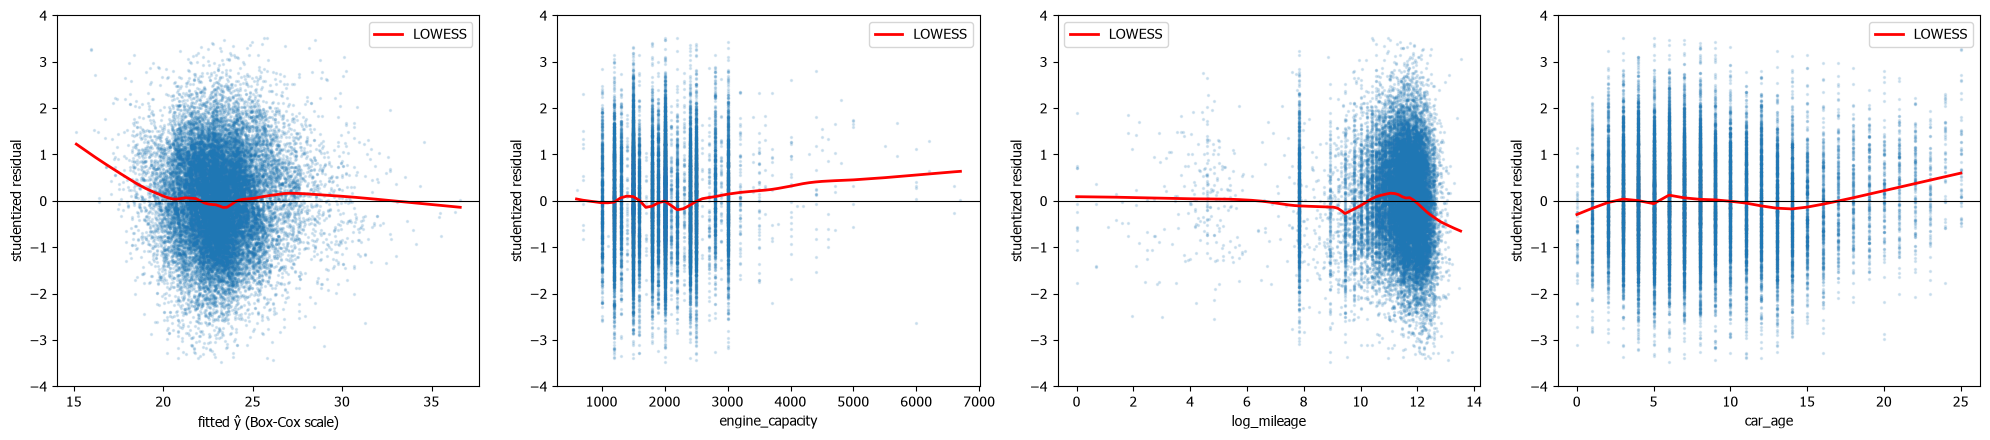

fitted ŷ (Box-Cox scale)   LOWESS ต่ำสุด -0.144  สูงสุด +1.222
engine_capacity            LOWESS ต่ำสุด -0.196  สูงสุด +0.635
log_mileage                LOWESS ต่ำสุด -0.653  สูงสุด +0.163
car_age                    LOWESS ต่ำสุด -0.296  สูงสุด +0.597


In [15]:
from statsmodels.nonparametric.smoothers_lowess import lowess

r = final["r"]
train_r = train_n.loc[r.index]   # แถว train ที่ตรงกับ residual (ตัวแปรดิบ ไม่ใช่ค่าที่ centre)
panels = [("fitted ŷ (Box-Cox scale)", final["fit"]),
          ("engine_capacity", train_r["engine_capacity"].values),
          ("log_mileage", train_r["log_mileage"].values),
          ("car_age", train_r["car_age"].values)]
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))
for a, (name, x) in zip(ax, panels):
    a.scatter(x, r.values, s=2, alpha=.15)
    smooth = lowess(r.values, x, frac=0.3, it=0, delta=0.01 * (x.max() - x.min()))   # เส้น LOWESS = ค่าเฉลี่ยเลื่อนของ residual
    a.plot(smooth[:, 0], smooth[:, 1], c="red", lw=2, label="LOWESS")
    a.axhline(0, c="k", lw=.8)
    a.set_ylim(-4, 4)
    a.set_xlabel(name)
    a.set_ylabel("studentized residual")
    a.legend()
plt.tight_layout()
plt.show()

# ขนาดความโค้ง: ช่วงต่ำสุด-สูงสุดของเส้น LOWESS (หน่วยเดียวกับ residual ที่ SD ≈ 1)
for name, x in panels:
    smooth = lowess(r.values, x, frac=0.3, it=0, delta=0.01 * (x.max() - x.min()))
    print(f"{name:26s} LOWESS ต่ำสุด {smooth[:, 1].min():+.3f}  สูงสุด {smooth[:, 1].max():+.3f}")

## 8. กราฟ residual ของโมเดลสุดท้าย
ซ้าย: residual เทียบกับค่าที่ fit (ควรกระจายสม่ำเสมอรอบ 0 ไม่เป็นรูปกรวย/โค้ง) กลาง: Q-Q plot (จุดควรอยู่บนเส้นทแยง) ขวา: histogram เทียบกับ N(0,1)

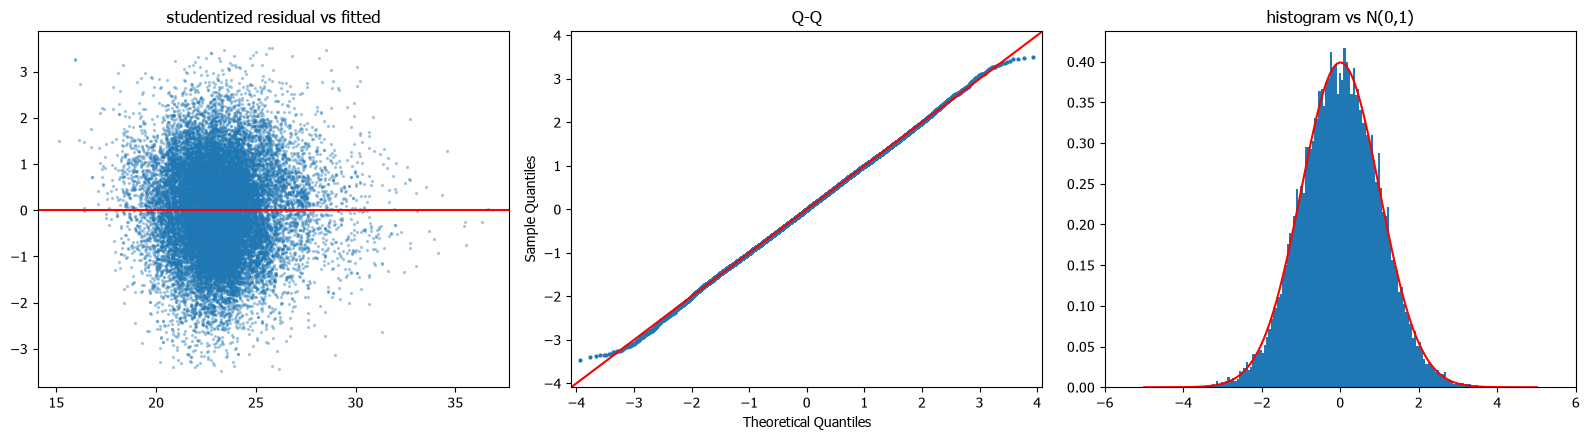

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
r = final["r"]
ax[0].scatter(final["fit"], r, s=2, alpha=.3)
ax[0].axhline(0, c="r")
ax[0].set_title("studentized residual vs fitted")
sm.qqplot(r, line="45", fit=True, ax=ax[1], markersize=2)
ax[1].set_title("Q-Q")
ax[2].hist((r - r.mean()) / r.std(), bins=120, density=True)
xs = np.linspace(-5, 5, 300)
ax[2].plot(xs, stats.norm.pdf(xs), c="r")
ax[2].set_xlim(-6, 6)
ax[2].set_title("histogram vs N(0,1)")
plt.tight_layout()
plt.show()

## 9. ตัวแปรแต่ละตัวสำคัญไหม (joint F-test บนโมเดลสุดท้าย)
H0: สัมประสิทธิ์ทุกตัวของตัวแปรนั้น = 0 (p < ALPHA แปลว่าตัวแปรนั้นช่วยอธิบายราคาจริง)

In [17]:
res = final["res"]
groups = {**{c: [c] for c in ["engine_capacity", "log_mileage", "km_unknown", "age_c2"] if c in X_tr.columns},
          "brand age slopes": [c for c in X_tr.columns if c.startswith("slope_")],
          **{c: [k for k in X_tr.columns if k.startswith(c + "_")] for c in MLR_CAT}}
ft_rows = []
for name, cols in groups.items():
    R = np.zeros((len(cols), len(res.params)))
    R[range(len(cols)), [res.params.index.get_loc(k) for k in cols]] = 1
    t = res.f_test(R)
    ft_rows.append(dict(feature=name, df=len(cols), F=float(np.squeeze(t.fvalue)), p_value=float(t.pvalue), significant=t.pvalue < ALPHA))
pd.DataFrame(ft_rows).set_index("feature").round(4)

,df,F,p_value,significant
feature,,,,
engine_capacity,1,230.4531,0.0000,True
log_mileage,1,1884.0957,0.0000,True
km_unknown,1,0.0007,0.9792,False
age_c2,1,543.7232,0.0000,True
brand age slopes,18,1687.6177,0.0000,True
model,327,1057.0876,0.0000,True
fuel_type,2,279.3626,0.0000,True
gear_type,1,1052.1668,0.0000,True
color,16,12.2590,0.0000,True


## 10. วัดผลบน val และ test (test ครั้งเดียว)
MLR ไม่มี hyperparameter ให้จูน (การเลือกตัวแปรทำใน train แล้ว) val จึงใช้ดูผลอย่างเดียว คำนวณ 4 ตัวชี้วัดบนราคาจริง (บาท):
- **RMSE** = รากของค่าเฉลี่ย error ยกกำลังสอง ลงโทษ error ใหญ่ ๆ หนัก
- **MAE** = ค่าเฉลี่ยของ error แบบไม่สนทิศทาง "พลาดเฉลี่ยกี่บาท"
- **MAPE** = error เฉลี่ยเป็นสัดส่วนของราคาจริง เช่น 0.11 = พลาด 11%
- **R²** = อธิบายความผันผวนของราคาได้กี่ส่วน

In [18]:
def score(actual, predicted):
    """วัดผลบนราคาจริง (บาท)"""
    return {
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "MAE": mean_absolute_error(actual, predicted),
        "MAPE": np.mean(np.abs(predicted / actual - 1)),
        "R2": r2_score(actual, predicted),
    }


test_pred = predict(final, X_te)
val_pred = predict(final, X_va)
pd.DataFrame({"val": score(val_n["price"], val_pred), "test": score(test_n["price"], test_pred)}).T.round(4)

,RMSE,MAE,MAPE,R2
val,206847.1008,85603.9569,0.1360,0.9173
test,282765.0773,88096.2834,0.1357,0.8020


### 10.1 ทำไม R² ของ val (0.917) กับ test (0.802) ต่างกันมาก
ดูแถวใน test ที่ทายพลาดมากที่สุด 10 แถว และดูว่า RMSE / R² เปลี่ยนไปเท่าไรถ้าไม่นับ 5 แถวแรก (**รายงานเท่านั้น** ไม่ได้ตัดแถวออกจากการวัดผลจริง)

In [19]:
test_err = test.assign(pred=test_pred)
test_err["abs_err"] = (test_err["pred"] - test_err["price"]).abs()
top10 = test_err.sort_values("abs_err", ascending=False).head(10)
display(top10[["brand", "model", "car_age", "price", "pred", "abs_err"]].round(0))

rows = [{"ชุดที่วัด": "test ทั้งหมด", "n": len(test_err), **score(test_err["price"], test_err["pred"])}]
for k in (1, 3, 5, 10):
    rest = test_err.drop(top10.index[:k])
    rows.append({"ชุดที่วัด": f"test ไม่นับ {k} แถวที่พลาดมากสุด", "n": len(rest), **score(rest["price"], rest["pred"])})
rows.append({"ชุดที่วัด": "val ทั้งหมด", "n": len(val_n), **score(val_n["price"], val_pred)})
display(pd.DataFrame(rows).set_index("ชุดที่วัด").round(4))
share = (top10["abs_err"].iloc[:5] ** 2).sum() / (test_err["abs_err"] ** 2).sum()
print(f"5 แถวที่พลาดมากสุดคิดเป็น {share:.1%} ของผลรวม error²")
print("ราคาสูงสุด val:", f"{val['price'].max():,.0f}", "| ราคาสูงสุด test:", f"{test['price'].max():,.0f}")

,brand,model,car_age,price,pred,abs_err
23557,LAND ROVER,RANGE ROVER,2,13990000,4306932.0,9683068.0
14074,LAND ROVER,RANGE ROVER,1,11490000,5227089.0,6262911.0
14462,MERCEDES-BENZ,MAYBACH S580,3,3690000,7475170.0,3785170.0
4986,SUBARU,IMPREZA,4,2090000,4979861.0,2889861.0
23885,MERCEDES-BENZ,S350,4,5990000,3177846.0,2812154.0
17618,BENTLEY,BENTAYGA,6,6590000,9350654.0,2760654.0
23902,PORSCHE,PANAMERA,4,7290000,5200985.0,2089015.0
23893,PORSCHE,CAYENNE,4,6290000,4468148.0,1821852.0
23861,PORSCHE,CAYENNE,6,4990000,3284518.0,1705482.0
13720,LAND ROVER,RANGE ROVER,7,4450000,2912659.0,1537341.0


,n,RMSE,MAE,MAPE,R2
ชุดที่วัด,,,,,
test ทั้งหมด,2982,282765.0773,88096.2834,0.1357,0.8020
test ไม่นับ 1 แถวที่พลาดมากสุด,2981,220294.7340,84877.5742,0.1355,0.8589
test ไม่นับ 3 แถวที่พลาดมากสุด,2979,174888.5199,81561.5870,0.1351,0.8984
test ไม่นับ 5 แถวที่พลาดมากสุด,2977,158571.2272,79701.0255,0.1345,0.9135
test ไม่นับ 10 แถวที่พลาดมากสุด,2972,135143.2932,76499.1954,0.1342,0.9244
val ทั้งหมด,2981,206847.1008,85603.9569,0.1360,0.9173


5 แถวที่พลาดมากสุดคิดเป็น 68.6% ของผลรวม error²
ราคาสูงสุด val: 12,990,000 | ราคาสูงสุด test: 13,990,000


**สรุปเรื่อง R² ของ val (0.917) กับ test (0.802):** MAE และ MAPE ของสองชุด **ใกล้กันมาก** (MAE 85.6k vs 88.1k บาท, MAPE 13.6% vs 13.6%) ความต่างของ R² และ RMSE มาจากรถแพงสุดไม่กี่คันใน test เกือบทั้งหมด: Range Rover อายุ 1-2 ปี 2 คัน (ราคา 13.99 ล้าน และ 11.49 ล้าน แต่โมเดลทาย 4.3 และ 5.2 ล้าน) ซึ่งเป็นรถที่แพงกว่าส่วนใหญ่ใน train มาก 5 แถวที่พลาดมากสุดคิดเป็น 68.6% ของผลรวม error² ของ test ถ้าไม่นับ 5 แถวนี้ RMSE ลดจาก 282,765 เหลือ 158,571 และ R² เพิ่มจาก 0.802 เป็น 0.914 (ใกล้ val) นี่เป็นเรื่องของรถหายาก/แพงมากที่ทายยากตามธรรมชาติ ไม่ใช่โมเดลแย่ลงโดยรวม **รายงานเท่านั้น ผลวัด test ด้านบนยังนับทุกแถว ไม่ได้ตัดแถวใดออก**

## 11. ราคาจริง vs ราคาที่ทำนาย (train / val / test)
แถวบนสเกลปกติ แถวล่างสเกล log จุดยิ่งใกล้เส้นประสีแดง ยิ่งทายแม่น

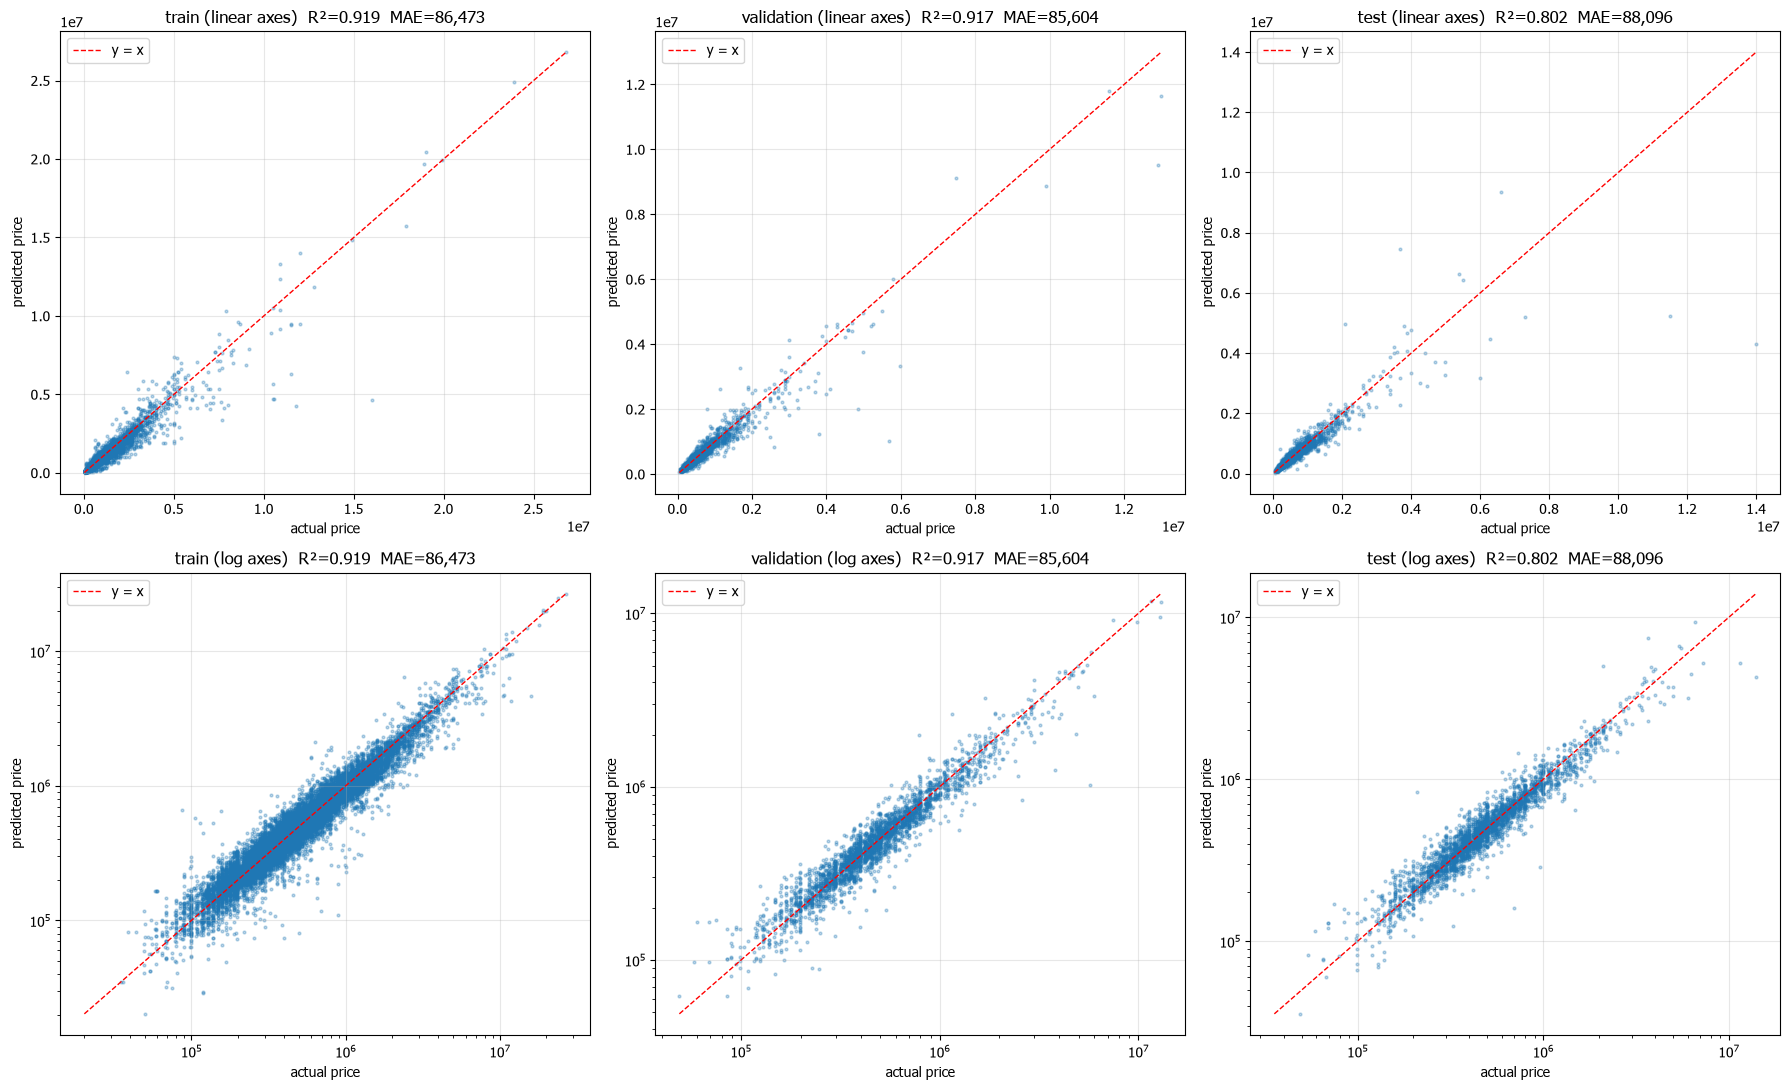

In [20]:
fig, ax = plt.subplots(2, 3, figsize=(18, 11))
for j, (name, d, X) in enumerate([("train", train_n.loc[final["keep"]], X_tr.loc[final["keep"]]), ("validation", val_n, X_va), ("test", test_n, X_te)]):
    actual, pred = d["price"].values, predict(final, X)
    for i, scale in enumerate(["linear", "log"]):
        a = ax[i, j]
        a.scatter(actual, pred, s=4, alpha=.3)
        lo, hi = min(actual.min(), pred.min()), max(actual.max(), pred.max())
        a.plot([lo, hi], [lo, hi], "r--", lw=1, label="y = x")
        a.set_xscale(scale)
        a.set_yscale(scale)
        a.grid(alpha=.3)
        a.legend()
        a.set_xlabel("actual price")
        a.set_ylabel("predicted price")
        a.set_title(f"{name} ({scale} axes)  R²={r2_score(actual, pred):.3f}  MAE={mean_absolute_error(actual, pred):,.0f}")
plt.tight_layout()
plt.show()

## 12. ทายพลาดตรงไหน (validation)
แยกตามอายุรถ และ 15 กลุ่มรุ่นที่พลาดมากที่สุด (เฉพาะกลุ่มที่มีอย่างน้อย 10 คัน)

In [21]:
errors = val_n.assign(pred=val_pred)
errors["abs_err"] = (errors["pred"] - errors["price"]).abs()   # พลาดกี่บาท
errors["ape"] = errors["abs_err"] / errors["price"]            # พลาดกี่ % ของราคา
errors["age_bin"] = pd.cut(errors["car_age"], [-1, 2, 5, 8, 12, 16, 20, 25])

by_age = errors.groupby("age_bin", observed=True).agg(
    n=("ape", "size"), MAE=("abs_err", "mean"), MAPE=("ape", "mean"))
display(by_age.round(3))

by_model = errors.groupby("model").agg(
    n=("ape", "size"), MAE=("abs_err", "mean"), MAPE=("ape", "mean"), med_price=("price", "median"))
by_model = by_model[by_model["n"] >= 10]
by_model.sort_values("MAE", ascending=False).head(15).round(3)

,n,MAE,MAPE
age_bin,,,
"(-1, 2]",176,199775.570,0.159
"(2, 5]",842,99551.033,0.110
"(5, 8]",879,78837.295,0.118
"(8, 12]",649,62394.649,0.133
"(12, 16]",314,60237.421,0.207
"(16, 20]",82,55610.779,0.218
"(20, 25]",39,75286.698,0.308


,n,MAE,MAPE,med_price
model,,,,
CAYENNE,20,335573.943,0.123,2940000.0
C220,13,271353.715,0.235,1490000.0
COOPER,10,226998.923,0.254,563000.0
C350,16,223154.744,0.234,584500.0
ALPHARD,41,221104.655,0.164,1675000.0
530E,22,220761.513,0.161,979000.0
E300,10,198898.228,0.150,1224500.0
E350,10,186839.969,0.139,854500.0
330E,11,176037.845,0.165,1090000.0


## 13. แบ่ง train/val/test อย่างไร และทำไม
กติกา (เจ้าของโปรเจกต์กำหนด): ลอง 80/10/10 ก่อน ถ้า MLR ไม่ผ่านครบทั้ง 5 กลุ่ม ให้ลอง 70/15/15, 75/12.5/12.5, 85/7.5/7.5 ตามลำดับ และหยุดที่ split แรกที่ผ่าน (seed, threshold, ALPHA, λ และการตั้งค่าโมเดลไม่เปลี่ยน)

| split | ผ่าน | test ที่ไม่ผ่าน |
|---|---|---|
| 80/10/10 | 15/16 | Ramsey RESET F = 51.80, p = 0.0000 |
| 70/15/15 | 15/16 | Ramsey RESET F = 35.53, p = 0.0000 |
| 75/12.5/12.5 | 15/16 | Ramsey RESET F = 50.79, p = 0.0000 |
| 85/7.5/7.5 | 15/16 | Ramsey RESET F = 71.45, p = 0.0000 |

**ผล:** ไม่มี split ไหนผ่านครบ 5 กลุ่ม (Independence, Homoscedasticity, Normality, Multicollinearity ผ่านทุก split มีเพียง Linearity / Ramsey RESET ที่ไม่ผ่าน) จึงคง 80/10/10 ไว้ตามกติกา notebook นี้จึงรันที่ 80/10/10